# 05 — Evaluation

Evaluate LightGBM on the held-out **test set** (last 15% of data, strictly chronological).

**Metrics:** Accuracy, Precision, Recall, F1, ROC-AUC  
**Plots:** Confusion matrices, ROC curves, calibration curves, feature importance  
**Final output:** Summary table — horizon × metric


In [1]:
import sys
from pathlib import Path

# Resolve project root robustly (works in VS Code Jupyter where CWD = workspace root)
try:
    ROOT = Path(__vsc_ipynb_file__).parent.parent.resolve()
except NameError:
    ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features import build_features, get_feature_cols, build_all_multitf
from src.models import LightGBMModel
from src.evaluate import (
    chronological_split,
    evaluate_model,
    plot_confusion_matrix,
    plot_roc_curves,
    plot_calibration,
    aggregate_results,
    print_results_table,
)

sns.set_theme(style='darkgrid', palette='muted')

PROCESSED  = ROOT / 'data' / 'processed'
MODEL_DIR  = ROOT / 'models'
HORIZONS   = ['5m', '15m', '30m', '1h']


## 1. Prepare Test Sets

In [2]:
# Load raw frames
raw_frames = {}
for label in HORIZONS:
    raw_frames[label] = pd.read_csv(
        PROCESSED / f"btc_{label}.csv",
        index_col="timestamp", parse_dates=True
    )

# Build features + multi-timeframe context
feat_frames = build_all_multitf(raw_frames)

flat_splits = {}
splits = {}

for label, df in feat_frames.items():
    train_df, val_df, test_df = chronological_split(df)
    splits[label] = (train_df, val_df, test_df)

    feat_cols = get_feature_cols(df)
    X_flat = df[feat_cols].values.astype(np.float32)
    y_flat = df["target"].values.astype(np.float32)
    n = len(y_flat)
    tr = int(n * 0.70)
    vl = int(n * 0.85)
    flat_splits[label] = (
        (X_flat[:tr],   y_flat[:tr]),
        (X_flat[tr:vl], y_flat[tr:vl]),
        (X_flat[vl:],   y_flat[vl:]),
    )


[features] Building features  (rows before: 758,593) …
[features] Dropped 98 NaN rows (indicator warm-up + label shift)
[features] Done  (rows after: 758,495,  features: 28)
[eval] Split → train 530,946  val 113,774  test 113,775  (2019-01-01 / 2024-01-18 / 2025-02-16)
[features] Building features  (rows before: 252,865) …
[features] Dropped 42 NaN rows (indicator warm-up + label shift)
[features] Done  (rows after: 252,823,  features: 28)
[eval] Split → train 176,976  val 37,923  test 37,924  (2019-01-01 / 2024-01-18 / 2025-02-16)
[features] Building features  (rows before: 126,433) …
[features] Dropped 34 NaN rows (indicator warm-up + label shift)
[features] Done  (rows after: 126,399,  features: 28)
[eval] Split → train 88,479  val 18,960  test 18,960  (2019-01-01 / 2024-01-19 / 2025-02-17)
[features] Building features  (rows before: 63,217) …
[features] Dropped 34 NaN rows (indicator warm-up + label shift)
[features] Done  (rows after: 63,183,  features: 28)
[eval] Split → train 44

## 2. Load Saved Models

In [3]:
lgbm_models = {}

for label in HORIZONS:
    m = LightGBMModel()
    m.load(MODEL_DIR / f'lgbm_{label}.pkl')
    lgbm_models[label] = m

print('All models loaded.')


[LGBM] Loaded ← /Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/models/lgbm_5m.pkl
[LGBM] Loaded ← /Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/models/lgbm_15m.pkl
[LGBM] Loaded ← /Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/models/lgbm_30m.pkl
[LGBM] Loaded ← /Users/ward/Desktop/aub/261/project/261_code/bitcoin-price-prediction/models/lgbm_1h.pkl
All models loaded.


## 3. Run Evaluation on Test Sets

In [4]:
all_results = {}  # {horizon: {model_name: metrics + raw preds}}

for label in HORIZONS:
    (_, _), (_, _), (X_te, y_te) = flat_splits[label]

    print(f'\n=== {label} ===')
    res = evaluate_model(lgbm_models[label], X_te, y_te)
    res['y_true'] = y_te
    all_results[label] = {'lgbm': res}
    print(f"  lgbm  acc={res['accuracy']:.4f}  "
          f"f1={res['f1']:.4f}  auc={res['roc_auc']:.4f}")



=== 5m ===
  lgbm  acc=0.5138  f1=0.4859  auc=0.5218

=== 15m ===
  lgbm  acc=0.5262  f1=0.5354  auc=0.5390

=== 30m ===
  lgbm  acc=0.5215  f1=0.5424  auc=0.5328

=== 1h ===
  lgbm  acc=0.5252  f1=0.5528  auc=0.5421


/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.11/site-p

## 4. Confusion Matrices

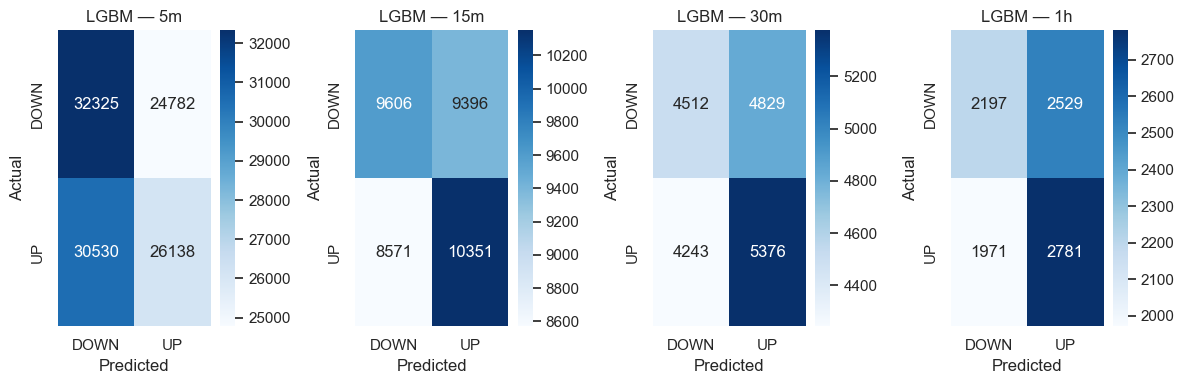

In [5]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(12, 4))

for ax, label in zip(axes, HORIZONS):
    res = all_results[label]['lgbm']
    plot_confusion_matrix(
        res['y_true'], res['y_pred'],
        title=f'LGBM — {label}',
        ax=ax,
    )

plt.tight_layout()
plt.show()


## 5. ROC Curves

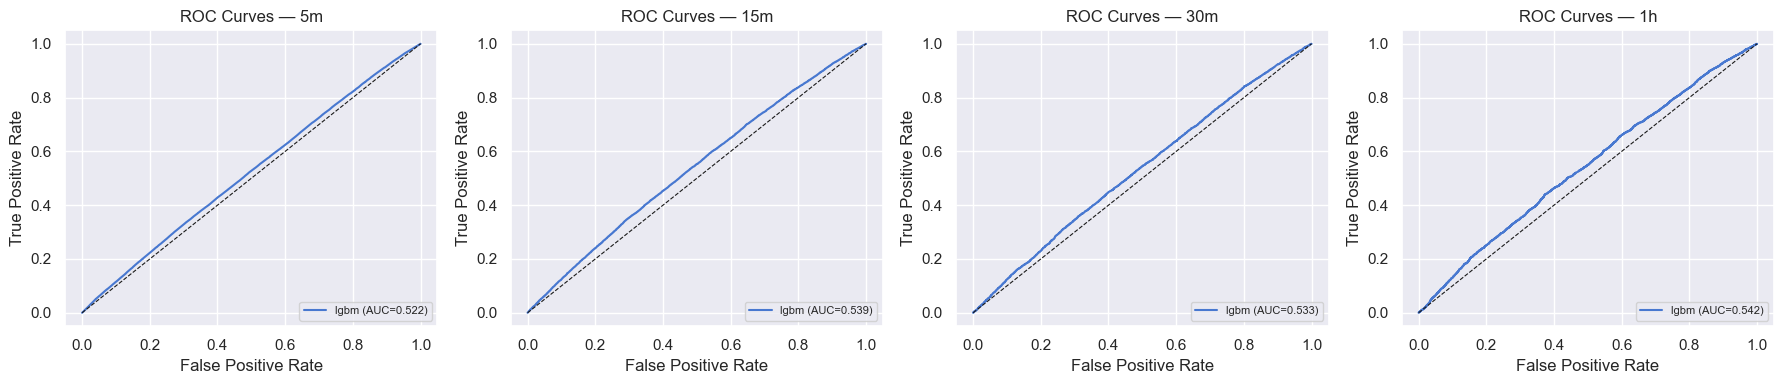

In [6]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, label in zip(axes, HORIZONS):
    plot_roc_curves(
        all_results[label],
        ax=ax,
        title=f'ROC Curves — {label}',
    )

plt.tight_layout()
plt.show()

## 6. Calibration Curves

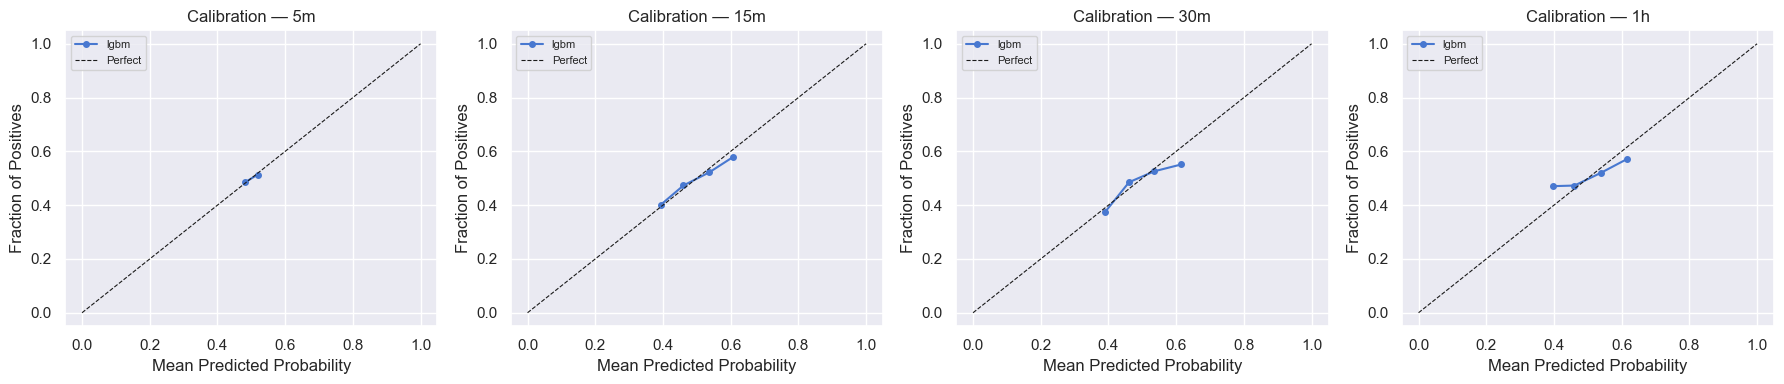

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, label in zip(axes, HORIZONS):
    plot_calibration(
        all_results[label],
        ax=ax,
        title=f'Calibration — {label}',
    )

plt.tight_layout()
plt.show()

## 7. Prediction Confidence Distribution

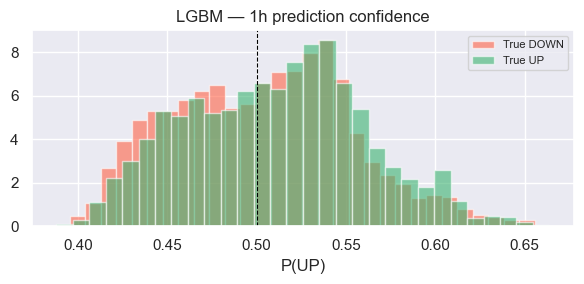

In [8]:
label = '1h'
res = all_results[label]['lgbm']
probs = res['y_prob']
true  = res['y_true'].astype(int)

fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(probs[true == 0], bins=30, alpha=0.6, color='tomato',
        density=True, label='True DOWN')
ax.hist(probs[true == 1], bins=30, alpha=0.6, color='mediumseagreen',
        density=True, label='True UP')
ax.axvline(0.5, color='black', linewidth=0.8, linestyle='--')
ax.set_title(f'LGBM — {label} prediction confidence')
ax.set_xlabel('P(UP)')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 8. Final Summary Table

In [9]:
results_df = aggregate_results(all_results)
print_results_table(results_df)

               accuracy  precision  recall      f1  roc_auc
horizon model                                              
5m      lgbm     0.5138     0.5133  0.4612  0.4859   0.5218
15m     lgbm     0.5262     0.5242  0.5470  0.5354   0.5390
30m     lgbm     0.5215     0.5268  0.5589  0.5424   0.5328
1h      lgbm     0.5252     0.5237  0.5852  0.5528   0.5421


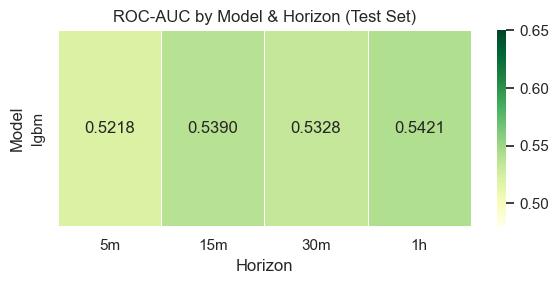

In [10]:
# Heatmap of ROC-AUC across model × horizon
auc_pivot = results_df['roc_auc'].unstack(level='horizon')[HORIZONS]

fig, ax = plt.subplots(figsize=(6, 3))
sns.heatmap(
    auc_pivot, annot=True, fmt='.4f', cmap='YlGn',
    vmin=0.48, vmax=0.65, linewidths=0.5, ax=ax,
)
ax.set_title('ROC-AUC by Model & Horizon (Test Set)')
ax.set_xlabel('Horizon')
ax.set_ylabel('Model')
plt.tight_layout()
plt.show()

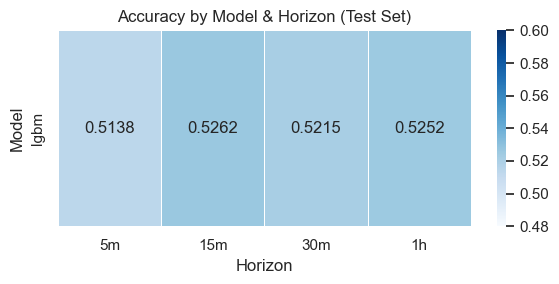

In [11]:
# Heatmap of Accuracy
acc_pivot = results_df['accuracy'].unstack(level='horizon')[HORIZONS]

fig, ax = plt.subplots(figsize=(6, 3))
sns.heatmap(
    acc_pivot, annot=True, fmt='.4f', cmap='Blues',
    vmin=0.48, vmax=0.60, linewidths=0.5, ax=ax,
)
ax.set_title('Accuracy by Model & Horizon (Test Set)')
ax.set_xlabel('Horizon')
ax.set_ylabel('Model')
plt.tight_layout()
plt.show()

## 9. Walk-Forward Validation

[LGBM] Training …
[LightGBM] [Info] Number of positive: 227751, number of negative: 227346
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003297 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6497
[LightGBM] [Info] Number of data points in the train set: 455097, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500445 -> initscore=0.001780
[LightGBM] [Info] Start training from score 0.001780
[LGBM] Best iteration: 0
[WFV] 5m  window 1/8  train=455,097  val=37,924  acc=0.5297  auc=0.5426
[LGBM] Training …


/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 246336, number of negative: 246685
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003804 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6497
[LightGBM] [Info] Number of data points in the train set: 493021, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499646 -> initscore=-0.001416
[LightGBM] [Info] Start training from score -0.001416
[LGBM] Best iteration: 0
[WFV] 5m  window 2/8  train=493,021  val=37,925  acc=0.5228  auc=0.5348
[LGBM] Training …


/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 265352, number of negative: 265594
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004790 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6497
[LightGBM] [Info] Number of data points in the train set: 530946, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499772 -> initscore=-0.000912
[LightGBM] [Info] Start training from score -0.000912
[LGBM] Best iteration: 0
[WFV] 5m  window 3/8  train=530,946  val=37,925  acc=0.5203  auc=0.5312
[LGBM] Training …


...

/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LGBM] Best iteration: 0
[WFV] 1h  window 7/8  train=56,864  val=3,159  acc=0.5378  auc=0.5477
[LGBM] Training …
[LightGBM] [Info] Number of positive: 30499, number of negative: 29524
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000453 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6497
[LightGBM] [Info] Number of data points in the train set: 60023, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.508122 -> initscore=0.032490
[LightGBM] [Info] Start training from score 0.032490


/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LGBM] Best iteration: 0
[WFV] 1h  window 8/8  train=60,023  val=3,160  acc=0.5234  auc=0.5357


/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


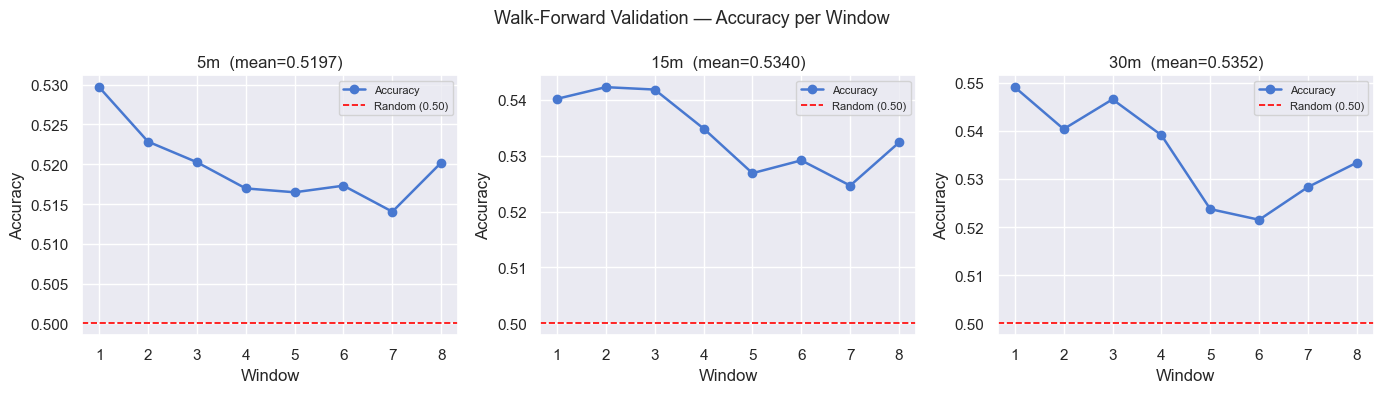


Walk-Forward Validation Summary
Horizon      Mean Acc    Std Acc
--------------------------------
5m             0.5197     0.0046
15m            0.5340     0.0064
30m            0.5352     0.0096
1h             0.5385     0.0086


In [12]:
# ── Section 9: Walk-Forward Validation ──────────────────────────────────────
# Expanding-window approach: initial training = 60%, each window adds ~5%.
# Validation window = next 5% of data after training end.
# 8 windows per horizon, fresh LightGBM trained on each window.

np.random.seed(42)

N_WINDOWS        = 8
INIT_TRAIN_FRAC  = 0.60   # first training window fraction
STEP_FRAC        = 0.05   # how much to grow training each window
VAL_FRAC         = 0.05   # validation window size

wfv_results = {}   # {horizon: {'acc': [...], 'auc': [...]}}

for label in HORIZONS:
    df = feat_frames[label]
    feat_cols = get_feature_cols(df)
    X_all = df[feat_cols].values.astype(np.float32)
    y_all = df['target'].values.astype(np.float32)
    n     = len(y_all)

    accs, aucs = [], []

    for w in range(N_WINDOWS):
        train_end = int(n * (INIT_TRAIN_FRAC + w * STEP_FRAC))
        val_end   = int(n * (INIT_TRAIN_FRAC + w * STEP_FRAC + VAL_FRAC))
        # Guard against running past the end of the data
        if val_end > n:
            print(f'[WFV] {label} window {w+1}: not enough data, skipping.')
            break

        X_tr, y_tr = X_all[:train_end],       y_all[:train_end]
        X_vl, y_vl = X_all[train_end:val_end], y_all[train_end:val_end]

        # Train a fresh LightGBM model (same default params as src/models.py)
        wfv_model = LightGBMModel()
        # Suppress verbose output by overriding n_estimators for speed;
        # keep all other hyper-parameters at their defaults.
        wfv_model.train(X_tr, y_tr)  # no validation set → no early stopping

        y_pred = wfv_model.predict(X_vl)
        y_prob = wfv_model.predict_proba(X_vl)

        from sklearn.metrics import accuracy_score, roc_auc_score
        acc = accuracy_score(y_vl, y_pred)
        try:
            auc = roc_auc_score(y_vl, y_prob)
        except Exception:
            auc = float('nan')

        accs.append(acc)
        aucs.append(auc)
        print(f'[WFV] {label}  window {w+1}/{N_WINDOWS}  '
              f'train={train_end:,}  val={val_end-train_end:,}  '
              f'acc={acc:.4f}  auc={auc:.4f}')

    wfv_results[label] = {'acc': accs, 'auc': aucs}

# ── Plot: accuracy per window, one subplot per horizon ────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)
fig.suptitle('Walk-Forward Validation — Accuracy per Window', fontsize=13)

for ax, label in zip(axes, HORIZONS):
    accs = wfv_results[label]['acc']
    windows = list(range(1, len(accs) + 1))
    mean_acc = np.mean(accs)

    ax.plot(windows, accs, marker='o', linewidth=1.8, label='Accuracy')
    ax.axhline(0.50, color='red', linestyle='--', linewidth=1.2, label='Random (0.50)')
    ax.set_title(f'{label}  (mean={mean_acc:.4f})')
    ax.set_xlabel('Window')
    ax.set_ylabel('Accuracy')
    ax.set_xticks(windows)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print('\nWalk-Forward Validation Summary')
print(f'{"Horizon":<10} {"Mean Acc":>10} {"Std Acc":>10}')
print('-' * 32)
for label in HORIZONS:
    accs = wfv_results[label]['acc']
    print(f'{label:<10} {np.mean(accs):>10.4f} {np.std(accs):>10.4f}')


## 10. Permutation Test

[Perm] 5m  real_acc=0.5138  null_mean=0.5002  p=0.0000
[Perm] 15m  real_acc=0.5262  null_mean=0.5001  p=0.0000
[Perm] 30m  real_acc=0.5215  null_mean=0.5006  p=0.0000
[Perm] 1h  real_acc=0.5252  null_mean=0.5000  p=0.0000


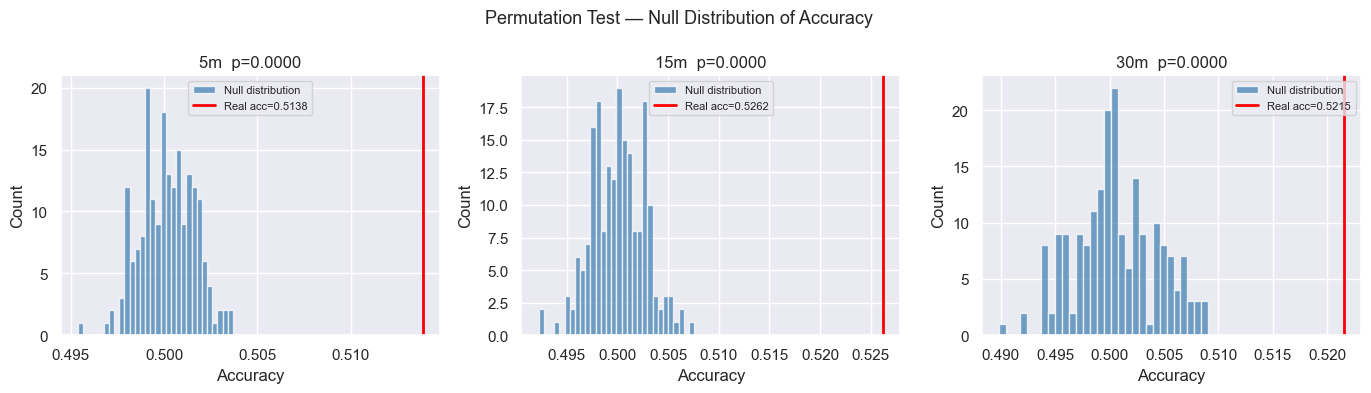


Permutation Test Conclusions (alpha = 0.05)
Horizon      Real Acc    p-value          Result
--------------------------------------------------
5m             0.5138     0.0000     SIGNIFICANT
15m            0.5262     0.0000     SIGNIFICANT
30m            0.5215     0.0000     SIGNIFICANT
1h             0.5252     0.0000     SIGNIFICANT


In [13]:
# ── Section 10: Permutation Test ────────────────────────────────────────────
# For each horizon: shuffle the true test labels 200 times and record the
# accuracy of the *real model's predictions* against the shuffled labels.
# p-value = fraction of permutations that reach or exceed the true accuracy.

np.random.seed(42)

N_PERMUTATIONS = 200

perm_results = {}   # {horizon: {'null_accs': [...], 'real_acc': float, 'pval': float}}

from sklearn.metrics import accuracy_score

for label in HORIZONS:
    res      = all_results[label]['lgbm']
    y_pred   = res['y_pred']          # real model predictions (fixed)
    y_test   = res['y_true']          # true labels from the held-out test set
    real_acc = accuracy_score(y_test, y_pred)

    null_accs = []
    for _ in range(N_PERMUTATIONS):
        y_shuffled = np.random.permutation(y_test)
        null_accs.append(accuracy_score(y_shuffled, y_pred))

    null_accs = np.array(null_accs)
    pval      = np.mean(null_accs >= real_acc)

    perm_results[label] = {
        'null_accs': null_accs,
        'real_acc':  real_acc,
        'pval':      pval,
    }
    print(f'[Perm] {label}  real_acc={real_acc:.4f}  '
          f'null_mean={null_accs.mean():.4f}  p={pval:.4f}')

# ── Plot: null distribution histograms ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Permutation Test — Null Distribution of Accuracy', fontsize=13)

for ax, label in zip(axes, HORIZONS):
    pr       = perm_results[label]
    real_acc = pr['real_acc']
    pval     = pr['pval']

    ax.hist(pr['null_accs'], bins=30, color='steelblue', edgecolor='white',
            alpha=0.75, label='Null distribution')
    ax.axvline(real_acc, color='red', linewidth=2.0,
               label=f'Real acc={real_acc:.4f}')
    ax.set_title(f'{label}  p={pval:.4f}')
    ax.set_xlabel('Accuracy')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# ── Conclusion ────────────────────────────────────────────────────────────────
print('\nPermutation Test Conclusions (alpha = 0.05)')
print(f'{"Horizon":<10} {"Real Acc":>10} {"p-value":>10} {"Result":>15}')
print('-' * 50)
for label in HORIZONS:
    pr     = perm_results[label]
    sig    = 'SIGNIFICANT' if pr['pval'] < 0.05 else 'NOT SIGNIFICANT'
    print(f'{label:<10} {pr["real_acc"]:>10.4f} {pr["pval"]:>10.4f} {sig:>15}')


### Live Prediction (Single-Shot)
Fetches the latest candles from Binance, builds features, and runs the LightGBM 1h model — no terminal needed.

In [14]:
import warnings, pickle
import numpy as np
import pandas as pd
from datetime import datetime, timezone
from binance.client import Client
from src.features import build_features, get_feature_cols

warnings.filterwarnings('ignore')

# Config
INTERVAL   = '1h'
N_CANDLES  = 248
MODEL_PATH = MODEL_DIR / 'lgbm_1h.pkl'
OHLCV_COLS = ['open', 'high', 'low', 'close', 'volume']

# Fetch latest candles from Binance
client = Client()
klines = client.get_klines(symbol='BTCUSDT', interval=INTERVAL, limit=N_CANDLES + 1)

df = pd.DataFrame(klines, columns=[
    'open_time','open','high','low','close','volume',
    'close_time','quote_volume','num_trades',
    'taker_buy_base','taker_buy_quote','ignore'
])
df['timestamp'] = pd.to_datetime(df['open_time'], unit='ms', utc=True)
df = df.set_index('timestamp')[OHLCV_COLS].astype(float)
df = df.iloc[:-1]  # drop still-open candle

# Build features
featured  = build_features(df, drop_na=False)
featured  = featured.dropna(subset=get_feature_cols(featured))

# Load model & predict
model     = pickle.load(open(MODEL_PATH, 'rb'))
feat_cols = get_feature_cols(featured)
X         = featured[feat_cols].values[-1:].astype(np.float32)
prob      = float(model.predict_proba(X)[0][1])

# Format output
direction  = 'UP  ▲' if prob >= 0.5 else 'DOWN ▼'
confidence = max(prob, 1 - prob) * 100
last_close = df['close'].iloc[-1]

now_utc    = datetime.now(timezone.utc)
now_local  = datetime.now().astimezone()
interval_ms = 3_600_000
now_ms     = int(now_utc.timestamp() * 1000)
next_start = datetime.fromtimestamp((now_ms // interval_ms) * interval_ms / 1000)
next_end   = datetime.fromtimestamp(((now_ms // interval_ms) + 1) * interval_ms / 1000)

print('=' * 55)
print('  BTC/USDT — Live Direction Prediction (LightGBM 1h)')
print('=' * 55)
print(f'  Time (UTC):        {now_utc.strftime("%Y-%m-%d %H:%M:%S")}')
print(f'  Time (Local):      {now_local.strftime("%Y-%m-%d %H:%M:%S %Z")}')
print(f'  Last close price:  ${last_close:,.2f}')
print(f'  Predicting candle: {next_start.strftime("%H:%M")} → {next_end.strftime("%H:%M")} (local)')
print('-' * 55)
print(f'  Direction:         {direction}')
print(f'  Confidence:        {confidence:.1f}%')
print(f'  P(UP):             {prob:.4f}')
print(f'  P(DOWN):           {1-prob:.4f}')
print('=' * 55)


[features] Building features  (rows before: 248) …
[features] Done  (rows after: 248,  features: 26)


ValueError: X has 26 features, but LGBMClassifier is expecting 28 features as input.